In [99]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

In [100]:
endtime = datetime.now()
starttime = endtime - timedelta(days= 365*5)
balance = 1000

In [101]:
stock = yf.download('SPY', start=starttime, end=endtime, auto_adjust=True)[['Close']]
stock.columns = stock.columns.get_level_values(0)



[*********************100%***********************]  1 of 1 completed


In [102]:
stock['log_returns'] = np.log(stock['Close'] / stock['Close'].shift(1))
stock['50_MA']  =  stock['Close'].rolling(window=50).mean()
stock['200_MA']  =  stock['Close'].rolling(window=200).mean()
stock.dropna(inplace=True)


In [103]:
stock['signal'] = np.where(stock['50_MA'] > stock['200_MA'], 1, 0)
stock['position'] = np.where(stock['signal'].shift(1) == 1, stock['log_returns'], 0)
stock.dropna(inplace=True)
stock['buy_&_hold'] = balance * np.exp(stock['log_returns'].cumsum())
stock['strategy_returns'] = balance * np.exp(stock['position'].cumsum())
stock

Price,Close,log_returns,50_MA,200_MA,signal,position,buy_&_hold,strategy_returns
Date,,,,,,,,
2022-01-04,450.493530,-0.000335,438.057470,410.713503,1,0.000000,999.665125,1000.000000
2022-01-05,441.843048,-0.019389,438.329621,411.103786,1,-0.019389,980.469322,980.797766
2022-01-06,441.428009,-0.000940,438.585765,411.501241,1,-0.000940,979.548332,979.876467
2022-01-07,439.682800,-0.003961,438.844982,411.879789,1,-0.003961,975.675636,976.002474
2022-01-10,439.135712,-0.001245,439.010908,412.226274,1,-0.001245,974.461622,974.788054
...,...,...,...,...,...,...,...,...
2026-03-16,667.207886,0.010125,684.255885,655.052510,1,0.010125,1480.563892,1336.951485
2026-03-17,668.963013,0.002627,684.008959,655.480512,1,0.002627,1484.458597,1340.468410
2026-03-18,659.628540,-0.014052,683.484591,655.865105,1,-0.014052,1463.744988,1321.763989


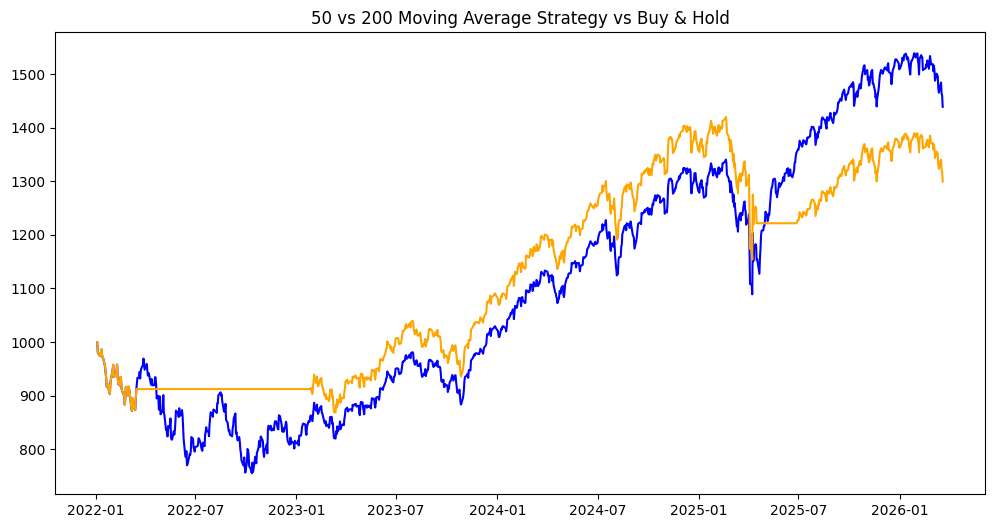

In [104]:
plt.figure(figsize=(12,6))
plt.plot(stock['buy_&_hold'], label='Buy & Hold', color='blue')
plt.plot(stock['strategy_returns'], label='50 vs 200 MA Strategy', color='orange')
plt.title('50 vs 200 Moving Average Strategy vs Buy & Hold')
plt.show()

In [105]:
buy_and_hold = stock['buy_&_hold'].copy()
strategy = stock['strategy_returns'].copy()
risk_free_rate = 0.04

In [106]:
buy_and_hold_SR = (buy_and_hold.pct_change().mean() - risk_free_rate/252) / buy_and_hold.pct_change().std() * np.sqrt(252)
strategy_SR = (strategy.pct_change().mean() - risk_free_rate/252) / strategy.pct_change().std() * np.sqrt(252)
print(f"Buy & Hold Sharpe Ratio: {buy_and_hold_SR:.2f}")
print(f"50 vs 200 MA Strategy Sharpe Ratio: {strategy_SR:.2f}")

Buy & Hold Sharpe Ratio: 0.35
50 vs 200 MA Strategy Sharpe Ratio: 0.23


In [114]:
def calculate_max_drawdown(series):
    cumulative_max = series.cummax()
    drawdown = (series - cumulative_max) / cumulative_max
    max_drawdown = drawdown.min()
    return max_drawdown

buy_and_hold_drawdown = calculate_max_drawdown(buy_and_hold)
strategy_drawdown = calculate_max_drawdown(strategy)
print(f"Buy & Hold Max Drawdown: {buy_and_hold_drawdown:.2%}")
print(f"50 vs 200 MA Strategy Max Drawdown: {strategy_drawdown:.2%}")


Buy & Hold Max Drawdown: -24.47%
50 vs 200 MA Strategy Max Drawdown: -18.76%
